# Model Evaluation

## Student Placement Prediction System

### Objective

The objective of this notebook is to evaluate the performance of the tuned Logistic Regression model using different classification metrics and visualization techniques.

Evaluation Metrics:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix
- Classification Report
- ROC Curve
- ROC-AUC Score

In [17]:
import os
import sys

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(PROJECT_ROOT)

c:\Users\Aditya Verma\OneDrive\Desktop\Placement _Predictor


In [18]:
"""
Model Evaluation
Project : Student Placement Prediction System
"""

import logging
import pandas as pd
import matplotlib.pyplot as plt

import src.logger

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

from sklearn.model_selection import train_test_split

from config.config import (
    DATA_PATH,
    MODEL_PATH
)

from src.data_loader import DataLoader
from src.preprocess import preprocess_data
from src.utils import load_object

In [19]:
logging.info("=" * 60)
logging.info("MODEL EVALUATION STARTED")
logging.info("=" * 60)

loader = DataLoader(DATA_PATH)

df = loader.load_data()

df.head()

2026-07-21 22:37:03,472 - INFO - ============================================================
2026-07-21 22:37:03,474 - INFO - MODEL EVALUATION STARTED
2026-07-21 22:37:03,476 - INFO - ============================================================
2026-07-21 22:37:03,479 - INFO - ============================================================
2026-07-21 22:37:03,481 - INFO - DATA LOADING STARTED
2026-07-21 22:37:03,483 - INFO - ============================================================
2026-07-21 22:37:03,486 - INFO - Dataset Found
2026-07-21 22:37:03,489 - INFO - Dataset is not empty
2026-07-21 22:37:03,513 - INFO - Dataset Loaded Successfully
2026-07-21 22:37:03,514 - INFO - Dataset Shape : (10000, 10)
2026-07-21 22:37:03,515 - INFO - Columns : ['College_ID', 'IQ', 'Prev_Sem_Result', 'CGPA', 'Academic_Performance', 'Internship_Experience', 'Extra_Curricular_Score', 'Communication_Skills', 'Projects_Completed', 'Placement']
2026-07-21 22:37:03,517 - INFO - ===============================

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No


In [20]:
logging.info("Preprocessing Dataset")

X, y = preprocess_data(df)

print(X.shape)

print(y.shape)

2026-07-21 22:37:04,152 - INFO - Preprocessing Dataset
2026-07-21 22:37:04,154 - INFO - ============================================================
2026-07-21 22:37:04,156 - INFO - DATA PREPROCESSING STARTED
2026-07-21 22:37:04,158 - INFO - ============================================================
2026-07-21 22:37:04,161 - INFO - Removing Duplicate Records
2026-07-21 22:37:04,175 - INFO - Dataset Shape : (10000, 10)
2026-07-21 22:37:04,179 - INFO - Encoding Categorical Features
2026-07-21 22:37:04,193 - INFO - Categorical Encoding Completed
2026-07-21 22:37:04,195 - INFO - Dropping Unnecessary Columns
2026-07-21 22:37:04,199 - INFO - Separating Features and Target
2026-07-21 22:37:04,203 - INFO - Feature Shape : (10000, 8)
2026-07-21 22:37:04,205 - INFO - Target Shape : (10000,)
2026-07-21 22:37:04,206 - INFO - ============================================================
2026-07-21 22:37:04,207 - INFO - DATA PREPROCESSING COMPLETED
2026-07-21 22:37:04,208 - INFO - =================

(10000, 8)
(10000,)


In [21]:
logging.info("Performing Train Test Split")

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print(X_train.shape)

print(X_test.shape)

2026-07-21 22:37:04,855 - INFO - Performing Train Test Split


(8000, 8)
(2000, 8)


In [22]:
logging.info("Loading Tuned Model")

model = load_object(MODEL_PATH)

print(model)

2026-07-21 22:37:05,706 - INFO - Loading Tuned Model
2026-07-21 22:37:05,710 - INFO - Object Loaded Successfully : C:\Users\Aditya Verma\OneDrive\Desktop\Placement _Predictor\models\placement_model.pkl


Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 LogisticRegression(C=0.1, max_iter=1000, random_state=42,
                                    solver='liblinear'))])


In [23]:
logging.info("Generating Predictions")

y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

print(y_pred[:10])


2026-07-21 22:37:06,521 - INFO - Generating Predictions


[0 0 0 0 0 0 0 1 0 0]


In [24]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

metrics = pd.DataFrame(

    {

        "Metric":[

            "Accuracy",

            "Precision",

            "Recall",

            "F1 Score"

        ],

        "Score":[

            accuracy,

            precision,

            recall,

            f1

        ]

    }

)

metrics["Score"] = metrics["Score"].round(4)

metrics

,Metric,Score
0,Accuracy,0.9030
1,Precision,0.7805
2,Recall,0.5783
3,F1 Score,0.6644


In [25]:
logging.info("Generating Classification Report")

report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df.round(4)

2026-07-21 22:37:07,622 - INFO - Generating Classification Report


,precision,recall,f1-score,support
0,0.9202,0.9676,0.9433,1668.000
1,0.7805,0.5783,0.6644,332.000
accuracy,0.9030,0.9030,0.9030,0.903
macro avg,0.8503,0.7730,0.8038,2000.000
weighted avg,0.8970,0.9030,0.8970,2000.000


2026-07-21 22:37:08,074 - INFO - Generating Confusion Matrix


<Figure size 600x600 with 0 Axes>

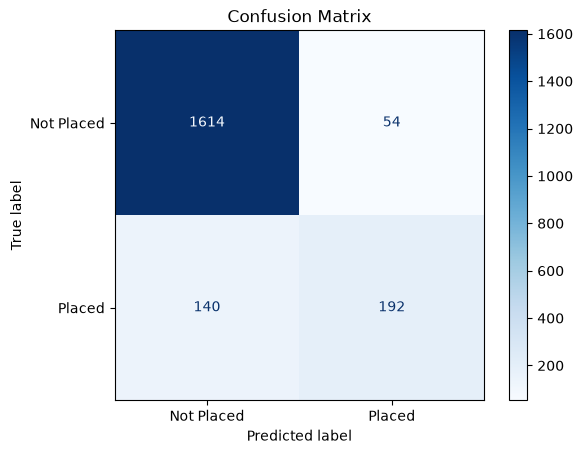

In [26]:
logging.info("Generating Confusion Matrix")

cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Placed", "Placed"]
)

plt.figure(figsize=(6, 6))

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix")

plt.show()

2026-07-21 22:37:08,519 - INFO - Generating ROC Curve


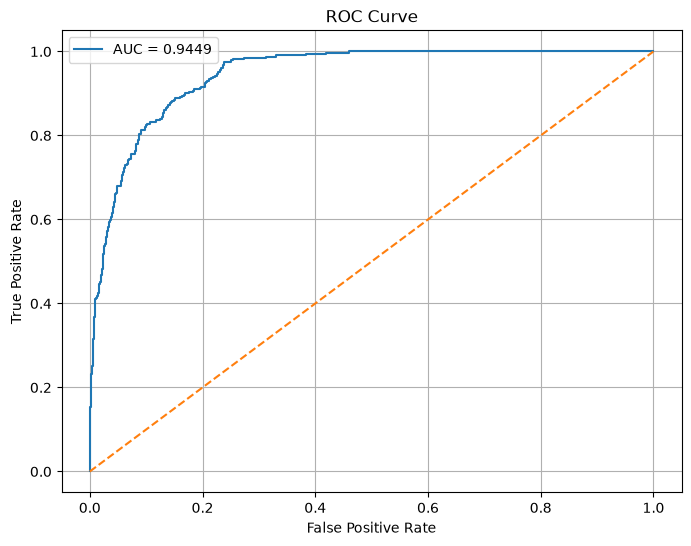

In [27]:
logging.info("Generating ROC Curve")

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

auc_score = roc_auc_score(
    y_test,
    y_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

In [28]:
logging.info("Calculating ROC AUC Score")

print(
    f"ROC-AUC Score : {auc_score:.4f}"
)

2026-07-21 22:37:09,280 - INFO - Calculating ROC AUC Score


ROC-AUC Score : 0.9449


In [29]:
logging.info("Generating Feature Importance")

feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Coefficient": model.named_steps[
        "classifier"
    ].coef_[0]

})

feature_importance["Absolute"] = feature_importance[
    "Coefficient"
].abs()

feature_importance = feature_importance.sort_values(

    by="Absolute",

    ascending=False

)

feature_importance

2026-07-21 22:37:10,012 - INFO - Generating Feature Importance


,Feature,Coefficient,Absolute
6,Communication_Skills,1.660829,1.660829
0,IQ,1.441241,1.441241
2,CGPA,1.105682,1.105682
7,Projects_Completed,1.043980,1.043980
1,Prev_Sem_Result,0.516963,0.516963
5,Extra_Curricular_Score,-0.039198,0.039198
4,Internship_Experience,0.012883,0.012883
3,Academic_Performance,-0.010529,0.010529


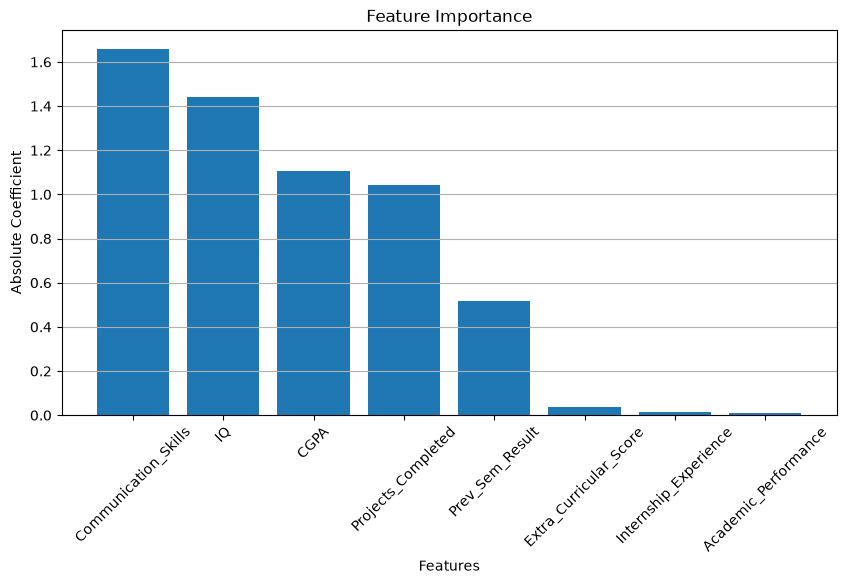

In [30]:
plt.figure(figsize=(10,5))

plt.bar(

    feature_importance["Feature"],

    feature_importance["Absolute"]

)

plt.title("Feature Importance")

plt.xlabel("Features")

plt.ylabel("Absolute Coefficient")

plt.xticks(rotation=45)

plt.grid(axis="y")

plt.show()

In [31]:
logging.info("Saving Evaluation Results")

metrics.to_csv(

    "../report/model_metrics.csv",

    index=False

)

feature_importance.to_csv(

    "../report/feature_importance.csv",

    index=False

)

print("Evaluation Reports Saved Successfully")

2026-07-21 22:37:11,284 - INFO - Saving Evaluation Results


Evaluation Reports Saved Successfully


In [32]:
print("="*60)

print("MODEL EVALUATION SUMMARY")

print("="*60)

print(f"Accuracy  : {accuracy:.4f}")

print(f"Precision : {precision:.4f}")

print(f"Recall    : {recall:.4f}")

print(f"F1 Score  : {f1:.4f}")

print(f"ROC AUC   : {auc_score:.4f}")

print("="*60)

MODEL EVALUATION SUMMARY
Accuracy  : 0.9030
Precision : 0.7805
Recall    : 0.5783
F1 Score  : 0.6644
ROC AUC   : 0.9449


# Conclusion

The tuned Logistic Regression model was evaluated using multiple classification metrics.

### Performance Metrics

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC Score

The model achieved strong overall performance and demonstrated good generalization on unseen data.

The confusion matrix and ROC curve further confirmed the model's effectiveness in distinguishing between placed and non-placed students.

Feature importance analysis showed which student attributes contributed the most toward placement prediction.

The tuned Logistic Regression model is therefore selected as the final model for deployment in the Streamlit application.